# Kidney + pancreas manuscript figures

This notebook is **visualization only**. It consumes frozen benchmark-ready `.h5ad` files and numerical benchmark outputs. It does not rerun classifiers or preprocessing.

It provides: preprocessing/dataset overview, UMAPs from the frozen PCA representation, random-vs-donor evaluation, donor ablation, per-class F1, representative confusion matrices, and the kidney/pancreas inflation-effect summary.

In [1]:
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / 'src' / 'scrna_benchmark').is_dir():
            return p
    raise RuntimeError('Run this notebook from inside the repository.')

REPO_ROOT = find_repo_root()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from scrna_benchmark.plotting import (
    DEFAULT_REP_LABELS,
    DEFAULT_REP_ORDER,
    load_per_class_f1_matrix,
    plot_confusion_matrix_from_predictions,
    plot_donor_ablation,
    plot_per_class_f1_heatmap,
    plot_random_vs_donor_cv,
)

FIG_DIR = REPO_ROOT / 'figures' / 'secondary_datasets'
CACHE_DIR = REPO_ROOT / 'results' / 'figure_data'
FIG_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    'kidney': {
        'adata': REPO_ROOT / 'data/kidney/kidney_benchmark_ready.h5ad',
        'results': REPO_ROOT / 'results/kidney_no_batch',
    },
    'pancreas': {
        'adata': REPO_ROOT / 'data/pancreas/pancreas_benchmark_ready.h5ad',
        'results': REPO_ROOT / 'results/pancreas_no_batch',
    },
}
print(REPO_ROOT)

/users/xchen5/scRNA-cross-donor-generalization


## 1. Numerical result availability

In [2]:
for dataset, paths in DATASETS.items():
    required = [
        paths['adata'],
        paths['results'] / 'random_split/random_split_repeated_metrics.csv',
        paths['results'] / 'donor_cv/metrics.csv',
        paths['results'] / 'donor_ablation/donor_ablation_summary.csv',
    ]
    missing = [p for p in required if not p.exists()]
    if missing:
        raise FileNotFoundError(f'{dataset}: missing required files: {missing}')
    print(dataset, 'OK')

kidney OK
pancreas OK


## 2. Dataset overview / preprocessing composition

In [3]:
overview_rows = []
for dataset, paths in DATASETS.items():
    adata = ad.read_h5ad(paths['adata'], backed='r')
    overview_rows.append({
        'dataset': dataset,
        'cells': adata.n_obs,
        'HVGs': adata.n_vars,
        'donors': adata.obs['donor_id'].astype(str).nunique(),
        'cell_types': adata.obs['cell_type'].astype(str).nunique(),
        'PCA_dims': adata.obsm['X_pca'].shape[1],
        'Harmony_dims': adata.obsm['X_harmony'].shape[1],
        'scVI_dims': adata.obsm['X_scVI'].shape[1],
    })
    if hasattr(adata, 'file') and adata.file is not None:
        adata.file.close()

overview = pd.DataFrame(overview_rows)
display(overview)

,dataset,cells,HVGs,donors,cell_types,PCA_dims,Harmony_dims,scVI_dims
0,kidney,8746,1000,19,9,15,15,15
1,pancreas,8500,1000,17,9,15,15,15


## 3. UMAPs from the frozen PCA representation

UMAP is treated as a **figure artifact**, not an experimental input. Coordinates are cached to `results/figure_data/` so figure regeneration does not mutate the benchmark-ready `.h5ad`.

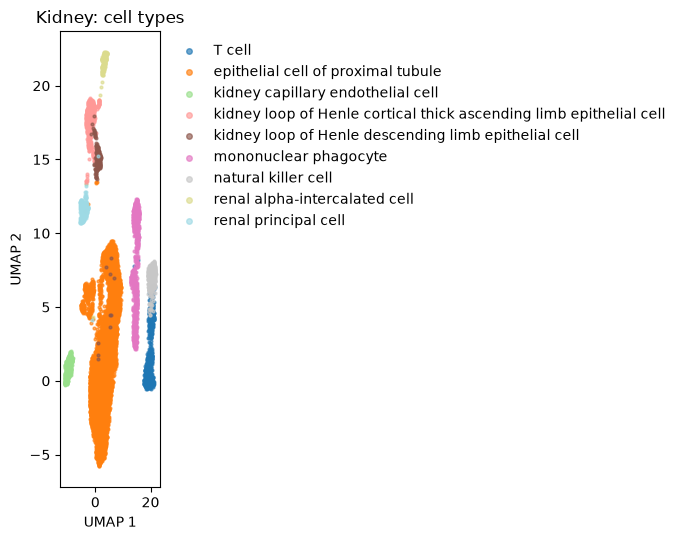

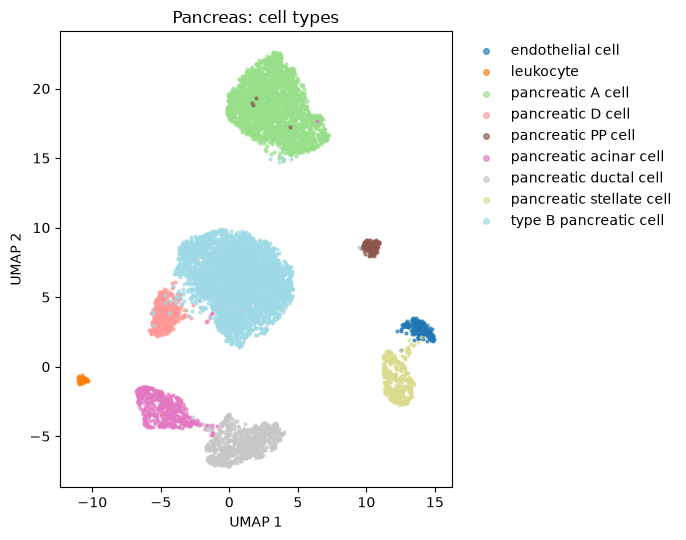

In [4]:
def get_or_make_umap(dataset, adata_path):
    cache = CACHE_DIR / f'{dataset}_umap_pca.csv'
    if cache.exists():
        coords = pd.read_csv(cache, index_col=0)
        return coords

    adata = ad.read_h5ad(adata_path)
    sc.pp.neighbors(adata, use_rep='X_pca', random_state=42)
    sc.tl.umap(adata, random_state=42)
    coords = pd.DataFrame(
        adata.obsm['X_umap'],
        index=adata.obs_names.astype(str),
        columns=['UMAP1', 'UMAP2'],
    )
    coords['cell_type'] = adata.obs['cell_type'].astype(str).to_numpy()
    coords['donor_id'] = adata.obs['donor_id'].astype(str).to_numpy()
    coords.to_csv(cache)
    return coords

for dataset, paths in DATASETS.items():
    coords = get_or_make_umap(dataset, paths['adata'])
    if 'cell_type' not in coords.columns:
        # Compatibility if an older coordinate-only cache exists.
        adata = ad.read_h5ad(paths['adata'], backed='r')
        meta = adata.obs[['cell_type', 'donor_id']].astype(str).copy()
        meta.index = meta.index.astype(str)
        coords = coords.join(meta)
        if hasattr(adata, 'file') and adata.file is not None:
            adata.file.close()

    fig, ax = plt.subplots(figsize=(7, 5.5))
    categories = sorted(coords['cell_type'].unique())
    cmap = plt.get_cmap('tab20', len(categories))
    for i, label in enumerate(categories):
        sub = coords[coords['cell_type'] == label]
        ax.scatter(sub['UMAP1'], sub['UMAP2'], s=4, alpha=0.65, label=label, color=cmap(i))
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(f'{dataset.capitalize()}: cell types')
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left', markerscale=2)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'{dataset}_umap_celltype.pdf', bbox_inches='tight')
    plt.show()

## 4. Random cell-level split vs donor-held-out CV

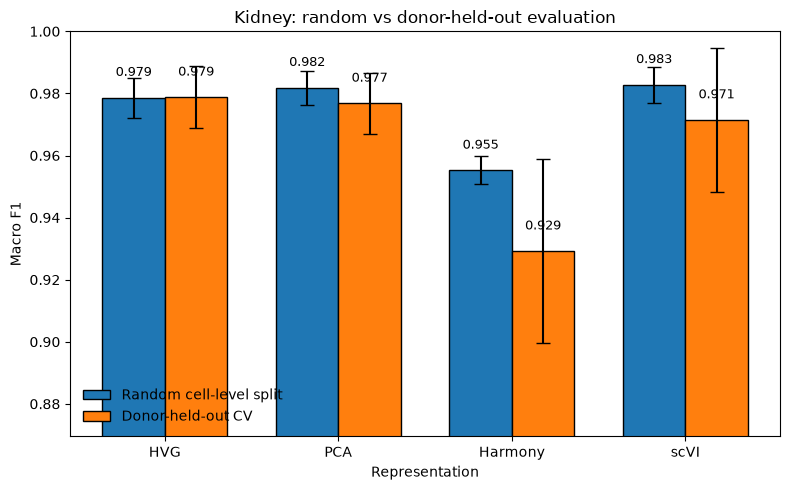

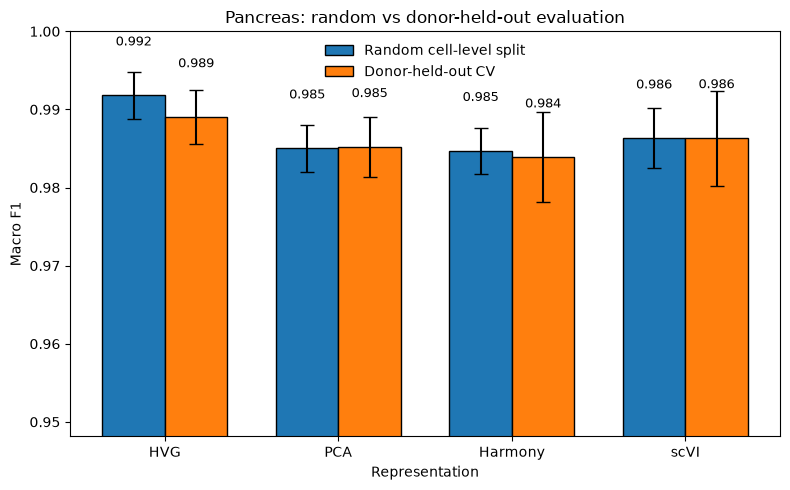

In [5]:
for dataset, paths in DATASETS.items():
    plot_random_vs_donor_cv(
        paths['results'] / 'random_split/random_split_repeated_metrics.csv',
        paths['results'] / 'donor_cv/metrics.csv',
        out_file=FIG_DIR / f'{dataset}_random_vs_donor.pdf',
        title=f'{dataset.capitalize()}: random vs donor-held-out evaluation',
    )
    plt.show()

## 5. Donor-ablation curves

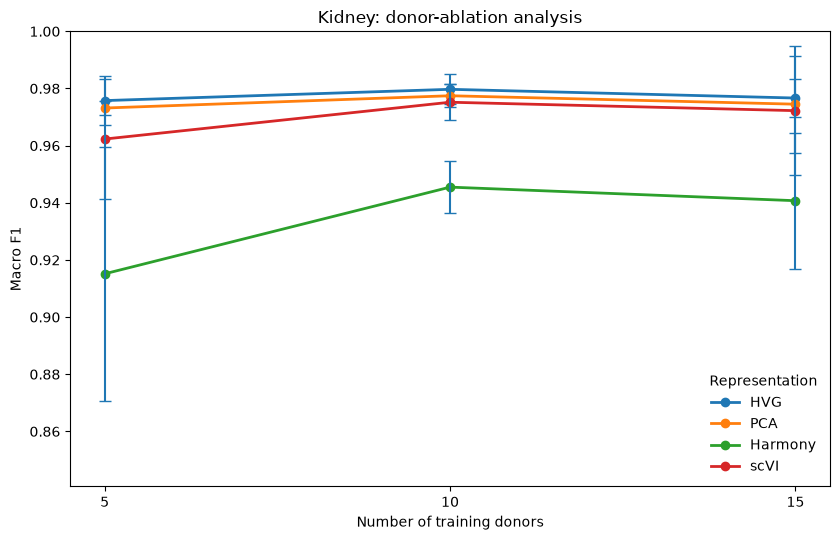

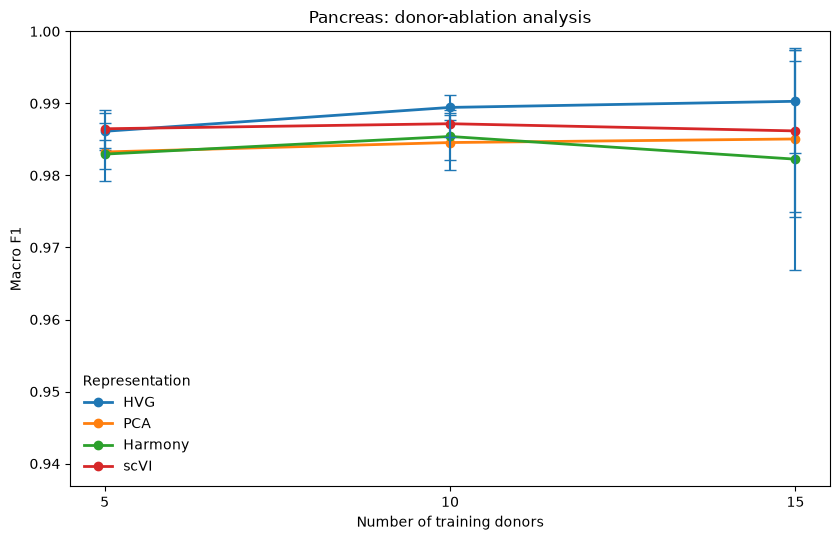

In [6]:
for dataset, paths in DATASETS.items():
    plot_donor_ablation(
        paths['results'] / 'donor_ablation/donor_ablation_summary.csv',
        out_file=FIG_DIR / f'{dataset}_donor_ablation.pdf',
        title=f'{dataset.capitalize()}: donor-ablation analysis',
    )
    plt.show()

## 6. Per-class donor-held-out F1

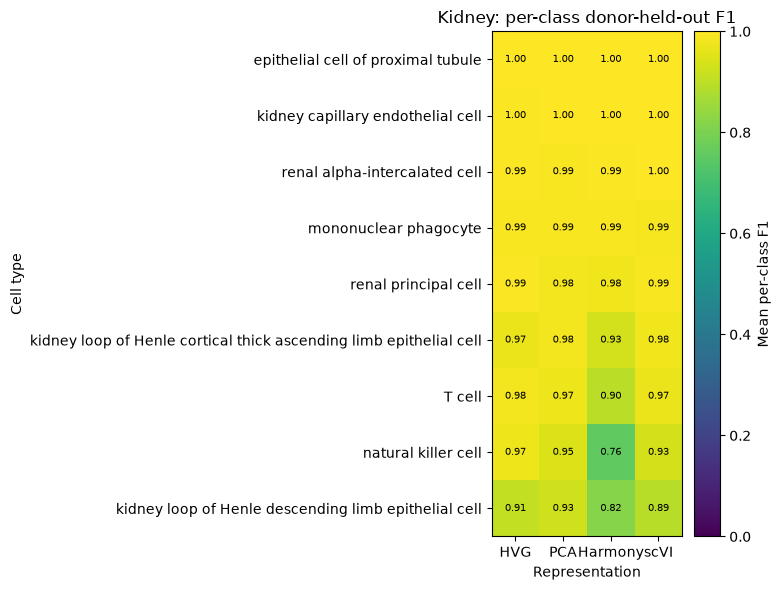

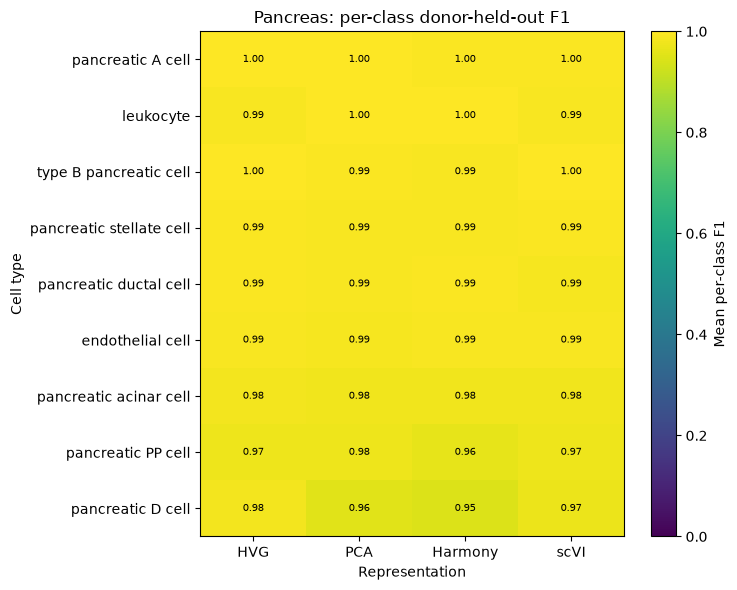

In [7]:
for dataset, paths in DATASETS.items():
    matrix = load_per_class_f1_matrix(paths['results'] / 'donor_cv')
    plot_per_class_f1_heatmap(
        matrix,
        out_file=FIG_DIR / f'{dataset}_per_class_f1.pdf',
        title=f'{dataset.capitalize()}: per-class donor-held-out F1',
    )
    plt.show()

## 7. Representative pooled confusion matrices

By default this uses scVI. Change `REPRESENTATIVE_REP` if the manuscript chooses another representation.

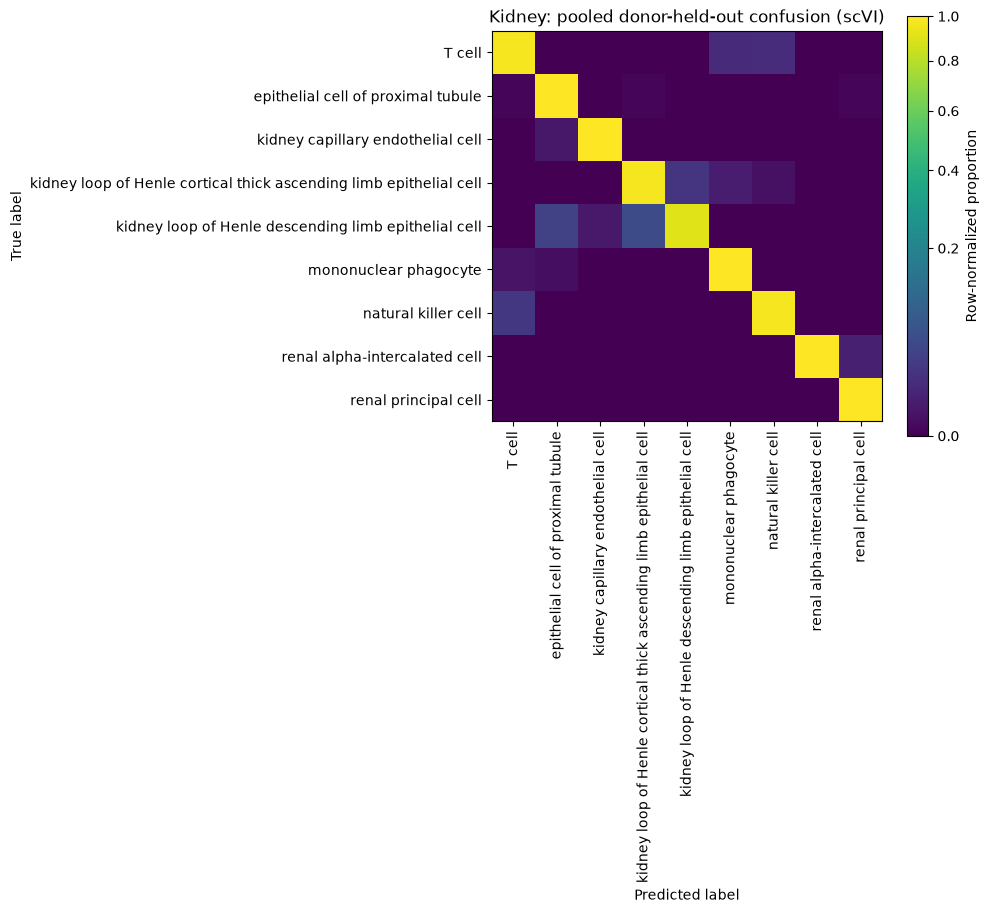

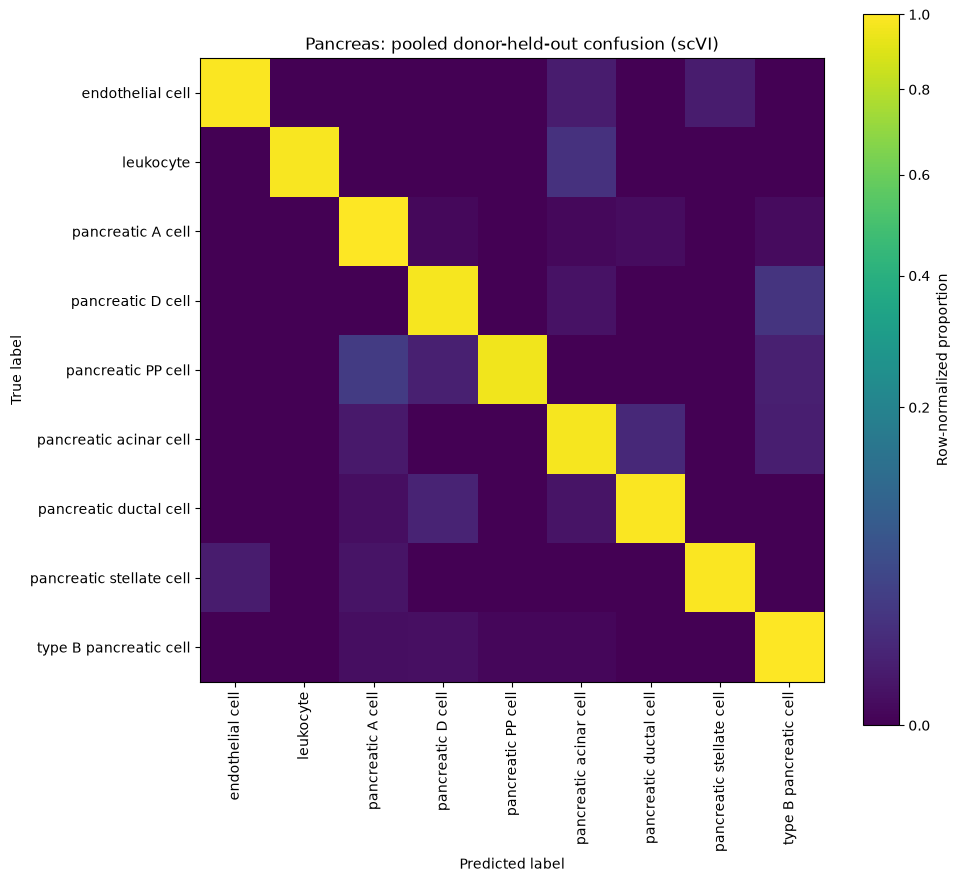

In [8]:
REPRESENTATIVE_REP = 'scvi'
for dataset, paths in DATASETS.items():
    pred = paths['results'] / 'donor_cv' / f'donor_cv_{REPRESENTATIVE_REP}_all_predictions.csv'
    plot_confusion_matrix_from_predictions(
        pred,
        out_file=FIG_DIR / f'{dataset}_{REPRESENTATIVE_REP}_confusion.pdf',
        title=f'{dataset.capitalize()}: pooled donor-held-out confusion ({DEFAULT_REP_LABELS[REPRESENTATIVE_REP]})',
    )
    plt.show()

## 8. Inflation effect summary

Define the evaluation inflation estimate as mean random-split macro F1 minus donor-held-out mean macro F1 for the same representation.

In [9]:
rows = []
for dataset, paths in DATASETS.items():
    random_df = pd.read_csv(paths['results'] / 'random_split/random_split_repeated_metrics.csv')
    donor_df = pd.read_csv(paths['results'] / 'donor_cv/metrics.csv')
    random_mean = random_df.groupby('representation', as_index=False)['macro_f1'].mean().rename(columns={'macro_f1':'random_macro_f1'})
    donor_keep = donor_df[['representation', 'macro_f1_mean']].rename(columns={'macro_f1_mean':'donor_macro_f1'})
    merged = random_mean.merge(donor_keep, on='representation', how='inner')
    merged['dataset'] = dataset
    merged['inflation_delta'] = merged['random_macro_f1'] - merged['donor_macro_f1']
    rows.append(merged)

inflation = pd.concat(rows, ignore_index=True)
display(inflation.sort_values(['dataset', 'representation']))
inflation.to_csv(CACHE_DIR / 'kidney_pancreas_inflation_summary.csv', index=False)

,representation,random_macro_f1,donor_macro_f1,dataset,inflation_delta
0,harmony,0.955212,0.929197,kidney,0.026015
1,hvg,0.978657,0.978761,kidney,-0.000103
2,pca,0.981869,0.976803,kidney,0.005066
3,scvi,0.982797,0.971453,kidney,0.011344
4,harmony,0.984691,0.983869,pancreas,0.000823
5,hvg,0.991803,0.989016,pancreas,0.002787
6,pca,0.985019,0.985191,pancreas,-0.000172
7,scvi,0.986298,0.986332,pancreas,-0.000034


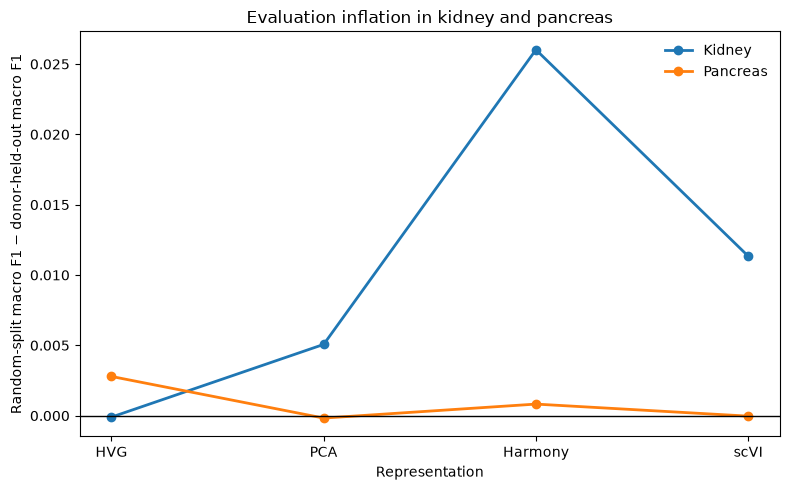

In [10]:
rep_order = [r for r in DEFAULT_REP_ORDER if r in set(inflation['representation'])]
x = np.arange(len(rep_order))
fig, ax = plt.subplots(figsize=(8, 5))
for dataset in DATASETS:
    sub = inflation[inflation['dataset'] == dataset].set_index('representation').reindex(rep_order)
    ax.plot(x, sub['inflation_delta'], marker='o', linewidth=2, label=dataset.capitalize())
ax.axhline(0, linewidth=1, color='black')
ax.set_xticks(x)
ax.set_xticklabels([DEFAULT_REP_LABELS.get(r, r) for r in rep_order])
ax.set_xlabel('Representation')
ax.set_ylabel('Random-split macro F1 − donor-held-out macro F1')
ax.set_title('Evaluation inflation in kidney and pancreas')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / 'kidney_pancreas_inflation_effect.pdf', bbox_inches='tight')
plt.show()

## Figure outputs

All exported panels are under `figures/secondary_datasets/`. The notebook intentionally keeps computation limited to visualization-derived artifacts (e.g., UMAP coordinates); benchmark metrics and predictions must already exist before this notebook runs.